# Exercise 1 - draw molecules

Draw the following molecules in a gridview including the molecule names.

Steps <details>

- Install and import the required libraries   
- convert data into a dataframe   
- convert smiles into mol objects and add to dataframe  
- draw the molecules in a gridview    

In [3]:
name = ["Linalool","Geraniol","Vanillin"]

smiles = ["CC(C)=CCC(C)(O)C=C",
          "CC(C)=CCC/C(C)=C/CO",
          "COc1cc(C=O)ccc1O"
          ]

Solution

In [4]:
# install rdkit
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 33.0 MB/s eta 0:00:00


In [5]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

In [6]:
df = pd.DataFrame({'name': name, 'smiles': smiles})
df

,name,smiles
0,Linalool,CC(C)=CCC(C)(O)C=C
1,Geraniol,CC(C)=CCC/C(C)=C/CO
2,Vanillin,COc1cc(C=O)ccc1O


In [7]:
# add mol
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df

,name,smiles,mol
0,Linalool,CC(C)=CCC(C)(O)C=C,<rdkit.Chem.rdchem.Mol object at 0x7e836e01ec00>
1,Geraniol,CC(C)=CCC/C(C)=C/CO,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fdf0>
2,Vanillin,COc1cc(C=O)ccc1O,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fb50>


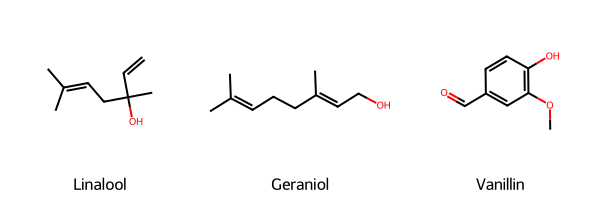

In [8]:
# draw molecules
img = Draw.MolsToGridImage(
    df['mol'].to_list(),
    molsPerRow=3,
    subImgSize=(200,200),
    legends=df['name'].to_list()
)
img

# Exercise 2 - add features

Add the following features to the dataframe:
- MW (Molecular weight)
- TPSA (Topological Polar Surface Area)
- MolLogP (logP)

Also Add  
- Morgan fingerprint (use Radius=2, Length = 2048)

Solution

In [9]:
# add descriptors MW, TPSA and MolLogP
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

df['MW'] = df['mol'].apply(Descriptors.MolWt)
df['TPSA'] = df['mol'].apply(rdMolDescriptors.CalcTPSA)
df['MolLogP'] = df['mol'].apply(Descriptors.MolLogP)
df

# or via a loop (slower, less efficient)


,name,smiles,mol,MW,TPSA,MolLogP
0,Linalool,CC(C)=CCC(C)(O)C=C,<rdkit.Chem.rdchem.Mol object at 0x7e836e01ec00>,140.226,20.23,2.2797
1,Geraniol,CC(C)=CCC/C(C)=C/CO,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fdf0>,154.253,20.23,2.6714
2,Vanillin,COc1cc(C=O)ccc1O,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fb50>,152.149,46.53,1.2133


**Calculating Descriptors via a Loop**

Although `apply` is generally more efficient for DataFrame operations, here's how you can calculate the molecular weight, TPSA, and MolLogP using a traditional loop for educational purposes. We'll re-initialize the DataFrame for this demonstration to show a clean calculation.

In [10]:
# Initialize empty lists to store descriptor values
mw_list = []
tpsa_list = []
logp_list = []

# Loop through each molecule in the 'mol' column
for mol_obj in df['mol']:
    mw_list.append(Descriptors.MolWt(mol_obj))
    tpsa_list.append(rdMolDescriptors.CalcTPSA(mol_obj))
    logp_list.append(Descriptors.MolLogP(mol_obj))

# Add the calculated descriptors as new columns to the DataFrame
df['MW'] = mw_list
df['TPSA'] = tpsa_list
df['MolLogP'] = logp_list

df

,name,smiles,mol,MW,TPSA,MolLogP
0,Linalool,CC(C)=CCC(C)(O)C=C,<rdkit.Chem.rdchem.Mol object at 0x7e836e01ec00>,140.226,20.23,2.2797
1,Geraniol,CC(C)=CCC/C(C)=C/CO,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fdf0>,154.253,20.23,2.6714
2,Vanillin,COc1cc(C=O)ccc1O,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fb50>,152.149,46.53,1.2133


In [11]:
# Add mogan fingerprint
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# Calculate fingerprints of all molecules in our DataFrame
# and add them to the DataFrame
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
morgan_fingerprints = []
for mol_obj in df["mol"]:
    fp = fpgen.GetFingerprint(mol_obj)
    morgan_fingerprints.append(list(fp))

df["morgan_fp"] = morgan_fingerprints
df

,name,smiles,mol,MW,TPSA,MolLogP,morgan_fp
0,Linalool,CC(C)=CCC(C)(O)C=C,<rdkit.Chem.rdchem.Mol object at 0x7e836e01ec00>,140.226,20.23,2.2797,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Geraniol,CC(C)=CCC/C(C)=C/CO,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fdf0>,154.253,20.23,2.6714,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Vanillin,COc1cc(C=O)ccc1O,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fb50>,152.149,46.53,1.2133,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


**Calculating Morgan Fingerprints via Lambda Function**

For a more concise way to apply a function to each element in a DataFrame column, especially for operations like fingerprint generation, you can use a `lambda` function directly with `apply`. We'll create a new DataFrame (`df_lambda`) to demonstrate this method separately.

In [12]:
# Calculate Morgan fingerprints using a lambda function
# The GetMorganFingerprintAsBitVect function returns a BitVector object
# We convert it to a list for easier storage in the DataFrame

fpgen_lambda = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
df['morgan_fp'] = df['mol'].apply(lambda x: list(fpgen_lambda.GetFingerprint(x)))

df

,name,smiles,mol,MW,TPSA,MolLogP,morgan_fp
0,Linalool,CC(C)=CCC(C)(O)C=C,<rdkit.Chem.rdchem.Mol object at 0x7e836e01ec00>,140.226,20.23,2.2797,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Geraniol,CC(C)=CCC/C(C)=C/CO,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fdf0>,154.253,20.23,2.6714,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Vanillin,COc1cc(C=O)ccc1O,<rdkit.Chem.rdchem.Mol object at 0x7e836e01fb50>,152.149,46.53,1.2133,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Exercise 3 - Pubchem

For the list of molecules provided:

1.  **Look up the SMILES strings** for each molecule from PubChem.
2.  **Draw all molecules** in a grid view, using their names as labels.
3. **Add 3 descriptors of your choice**

In [13]:
names = [
    "Caffeine",
    "Aspirin",
    "Vanillin",
    "Menthol",
    "Citric acid",
    "Glucose",
    "Nicotine",
    "Ibuprofen",
    "Paracetamol",
    "Limonene",
    "Phenol",
    "Cholesterol",
    "Capsaicin"
]

Solution

In [14]:
# Install PubChemPy
!pip install PubChemPy

In [15]:
import pubchempy as pcp

In [16]:
smiles_list = []
for compound_name in names:
  # Search by name in PubChem
  compounds = pcp.get_compounds(compound_name, 'name')
  smiles_list.append(compounds[0].canonical_smiles)
  print (compound_name)

/tmp/ipykernel_2082/3108905948.py:5: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles_list.append(compounds[0].canonical_smiles)


Caffeine
Aspirin
Vanillin
Menthol
Citric acid
Glucose
Nicotine
Ibuprofen
Paracetamol
Limonene
Phenol
Cholesterol
Capsaicin


In [17]:
smiles_list

['CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
 'CC(=O)OC1=CC=CC=C1C(=O)O',
 'COC1=C(C=CC(=C1)C=O)O',
 'CC1CCC(C(C1)O)C(C)C',
 'C(C(=O)O)C(CC(=O)O)(C(=O)O)O',
 'C(C1C(C(C(C(O1)O)O)O)O)O',
 'CN1CCCC1C2=CN=CC=C2',
 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
 'CC(=O)NC1=CC=C(C=C1)O',
 'CC1=CCC(CC1)C(=C)C',
 'C1=CC=C(C=C1)O',
 'CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C',
 'CC(C)C=CCCCCC(=O)NCC1=CC(=C(C=C1)O)OC']

In [18]:
# Convert smiles to mol objects and add to dataframe
df = pd.DataFrame({'name': names, 'smiles': smiles_list})
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df

,name,smiles,mol
0,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1e70>
1,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d2490>
2,Vanillin,COC1=C(C=CC(=C1)C=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d2d50>
3,Menthol,CC1CCC(C(C1)O)C(C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d0a50>
4,Citric acid,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d3f40>
5,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1070>
6,Nicotine,CN1CCCC1C2=CN=CC=C2,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d35a0>
7,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1f50>
8,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d0970>
9,Limonene,CC1=CCC(CC1)C(=C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d3530>


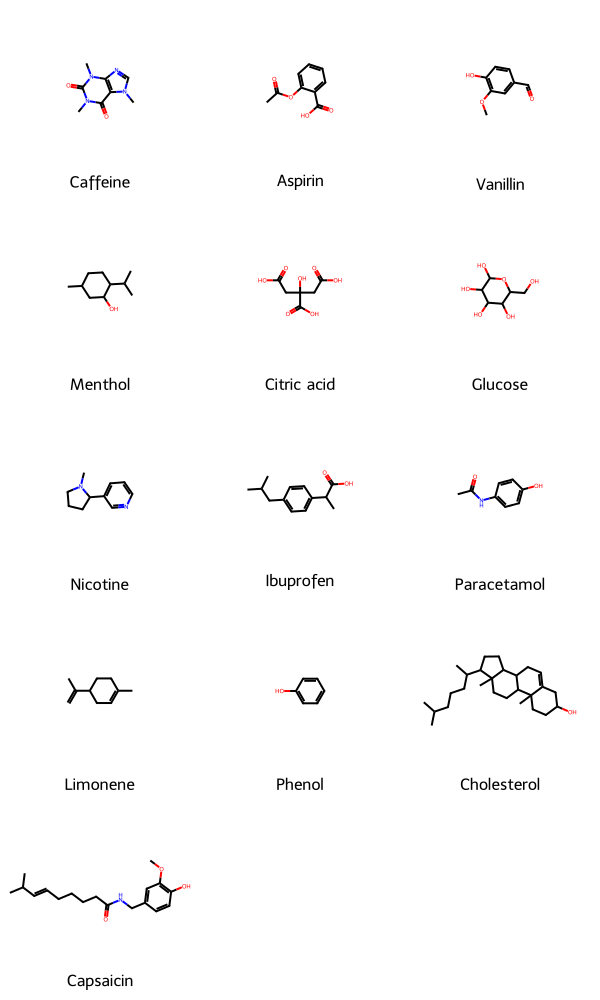

In [19]:
# draw
img = Draw.MolsToGridImage(
    df['mol'].to_list(),
    molsPerRow=3,
    subImgSize=(200,200),
    legends=df['name'].to_list()
)
img

In [21]:
# Add descriptors - Using Apply
df['MW'] = df['mol'].apply(Descriptors.MolWt)
df['TPSA'] = df['mol'].apply(rdMolDescriptors.CalcTPSA)
df['MolLogP'] = df['mol'].apply(Descriptors.MolLogP)
df

,name,smiles,mol,MW,TPSA,MolLogP
0,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1e70>,194.194,61.82,-1.0293
1,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d2490>,180.159,63.60,1.3101
2,Vanillin,COC1=C(C=CC(=C1)C=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d2d50>,152.149,46.53,1.2133
3,Menthol,CC1CCC(C(C1)O)C(C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d0a50>,156.269,20.23,2.4395
4,Citric acid,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d3f40>,192.123,132.13,-1.2485
5,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1070>,180.156,110.38,-3.2214
6,Nicotine,CN1CCCC1C2=CN=CC=C2,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d35a0>,162.236,16.13,1.8483
7,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1f50>,206.285,37.30,3.0732
8,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d0970>,151.165,49.33,1.3506
9,Limonene,CC1=CCC(CC1)C(=C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d3530>,136.238,0.00,3.3089


In [22]:
# Add descriptors - Using Loop

# Initialize empty lists to store descriptor values
mw_list = []
tpsa_list = []
logp_list = []

# Loop through each molecule in the 'mol' column
for mol_obj in df['mol']:
    mw_list.append(Descriptors.MolWt(mol_obj))
    tpsa_list.append(rdMolDescriptors.CalcTPSA(mol_obj))
    logp_list.append(Descriptors.MolLogP(mol_obj))
# Add the calculated descriptors as new columns to the DataFrame
df['MW'] = mw_list
df['TPSA'] = tpsa_list
df['MolLogP'] = logp_list

df

,name,smiles,mol,MW,TPSA,MolLogP
0,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1e70>,194.194,61.82,-1.0293
1,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d2490>,180.159,63.60,1.3101
2,Vanillin,COC1=C(C=CC(=C1)C=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d2d50>,152.149,46.53,1.2133
3,Menthol,CC1CCC(C(C1)O)C(C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d0a50>,156.269,20.23,2.4395
4,Citric acid,C(C(=O)O)C(CC(=O)O)(C(=O)O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d3f40>,192.123,132.13,-1.2485
5,Glucose,C(C1C(C(C(C(O1)O)O)O)O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1070>,180.156,110.38,-3.2214
6,Nicotine,CN1CCCC1C2=CN=CC=C2,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d35a0>,162.236,16.13,1.8483
7,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d1f50>,206.285,37.30,3.0732
8,Paracetamol,CC(=O)NC1=CC=C(C=C1)O,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d0970>,151.165,49.33,1.3506
9,Limonene,CC1=CCC(CC1)C(=C)C,<rdkit.Chem.rdchem.Mol object at 0x7e836c1d3530>,136.238,0.00,3.3089
